# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Mohamed Fathy Mahmoud Mohamed

ID: 43-17605

Tutorial: T-01

---

Name: Sherif Wael

ID: 43-2241

Tutorial: T-01

---


## Dataset Description

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

Each row represents a customer, and each column represents customer attributes as described below.

| Column | Description|
|-|-|
|gender|Whether the customer is a male or a female|
|SeniorCitizen| Whether the customer is a senior citizen or not (1, 0)|
|Partner|Whether the customer has a partner or not (Yes, No)|
|Dependents|Whether the customer has dependents or not (Yes, No)|
|tenure| Number of months the customer has stayed with the company|
|PhoneService|Whether the customer has a phone service or not (Yes, No)|
|MultipleLines|Whether the customer has multiple lines or not (Yes, No, No phone service*)|
|InternetService|Customer’s internet service provider (DSL, Fiber optic, No)|
|OnlineSecurity|Whether the customer has online security or not (Yes, No, No internet service**)|
|OnlineBackup|Whether the customer has online backup or not (Yes, No, No internet service)|
|DeviceProtection|Whether the customer has device protection or not (Yes, No, No internet service)|
|TechSupport|Whether the customer has tech support or not (Yes, No, No internet service)|
|StreamingTV|Whether the customer has streaming TV or not (Yes, No, No internet service) |
|StreamingMovies|Whether the customer has streaming movies or not (Yes, No, No internet service)|
|Contract|The contract term of the customer (Month-to-month, One year, Two year)|
|PaperlessBilling|Whether the customer has paperless billing or not (Yes, No)|
|PaymentMethod|The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))|
|MonthlyCharges|The amount charged to the customer monthly|
|TotalCharges|The total amount charged to the customer|
|Churn|Whether the customer churned or not (Yes or No)|

\* No phone service means the customer's plan does not include calling (could be a data-only plan)

\*\* No internet service means the customer's plan does not include internet/data and so the addon package does not apply

## Importing Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2021/main/data/telecom_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85/m,$29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,$56.95/m,$1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85/m,$108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),$42.3/m,$1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,$70.7/m,$151.65,Yes


## Data Inspection

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        6976 non-null   object
 1   gender            7032 non-null   object
 2   SeniorCitizen     7032 non-null   int64 
 3   Partner           7032 non-null   object
 4   Dependents        7032 non-null   object
 5   tenure            7032 non-null   int64 
 6   PhoneService      7032 non-null   object
 7   MultipleLines     7032 non-null   object
 8   InternetService   7032 non-null   object
 9   OnlineSecurity    7032 non-null   object
 10  OnlineBackup      7032 non-null   object
 11  DeviceProtection  7032 non-null   object
 12  TechSupport       7032 non-null   object
 13  StreamingTV       7032 non-null   object
 14  StreamingMovies   7032 non-null   object
 15  Contract          7032 non-null   object
 16  PaperlessBilling  7032 non-null   object
 17  PaymentMethod 

In [3]:
df['Churn'].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

In [4]:
df.describe(include='O')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,6976,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,6180,7032
unique,6976,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1584,5783,2
top,0439-IFYUN,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,$20.05/m,$19.65,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,61,8,5163


In [5]:
df.describe()

,SeniorCitizen,tenure
count,7032.000000,7032.000000
mean,0.162400,32.421786
std,0.368844,24.545260
min,0.000000,1.000000
25%,0.000000,9.000000
50%,0.000000,29.000000
75%,0.000000,55.000000
max,1.000000,72.000000


In [6]:
df.isna().sum()

customerID           56
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        852
Churn                 0
dtype: int64

In [7]:
categorical_col = []
for column in df.columns:
    if df[column].dtype == object and len(df[column].unique()) <= 50:
        categorical_col.append(column)
        print(f"{column} : {df[column].unique()}")
        print("====================================")

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


## Data Pre-processing

enocde Churn as 0 and 1

In [8]:
df['Churn'] = df['Churn'].astype('category').cat.codes
categorical_col.remove('Churn')
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int8

change type of senior citizen to categoical 

In [9]:
df['SeniorCitizen'] = pd.Categorical(df.SeniorCitizen)
categorical_col.append('SeniorCitizen')

Drop the customer ID column

In [10]:
df = df.drop('customerID', axis = 1)

clean the values of Monthly charges and total charges

In [11]:
print(df['MonthlyCharges'].map(lambda x: x[0]).value_counts())
print(df['MonthlyCharges'].map(lambda x: x[-2:]).value_counts())

$    7032
Name: MonthlyCharges, dtype: int64
/m    7032
Name: MonthlyCharges, dtype: int64


In [12]:
df['MonthlyCharges'] = df['MonthlyCharges'].map(lambda x: x.replace('$', ''))
df['MonthlyCharges'] = df['MonthlyCharges'].map(lambda x: float(x.replace('/m', '')))


In [13]:
print(df['TotalCharges'].dropna().map(lambda x: x[0]).value_counts())

$    6180
Name: TotalCharges, dtype: int64


In [14]:
df['TotalCharges'] = df['TotalCharges'].map(lambda x: float(x.replace('$', ''))  if not pd.isnull(x) else np.nan)

In [15]:
print(df['TotalCharges'])

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7027    1990.50
7028    7362.90
7029     346.45
7030     306.60
7031    6844.50
Name: TotalCharges, Length: 7032, dtype: float64


In [16]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,6180.000000,7032.000000
mean,32.421786,64.798208,2281.933932,0.265785
std,24.545260,30.085974,2271.511755,0.441782
min,1.000000,18.250000,18.850000,0.000000
25%,9.000000,35.587500,392.612500,0.000000
50%,29.000000,70.350000,1390.225000,0.000000
75%,55.000000,89.862500,3785.900000,1.000000
max,72.000000,118.750000,8684.800000,1.000000


### Fill the missing values in the total charges using regression

The values of the total charges can be imputed using regression with the attributes monthly charges and tenture

In [17]:
train_set = df[df['TotalCharges'].isnull()==False]
test_set = df[df['TotalCharges'].isnull()==True]
x_train = train_set[['tenure','MonthlyCharges']]
y_train = train_set['TotalCharges']

x_test = test_set[['tenure','MonthlyCharges']]
y_test = test_set['TotalCharges']

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
y_pred = linear_model.predict(x_test)

In [19]:
total_usingRegression = df.TotalCharges.fillna(pd.Series(y_pred,index=y_test.index))

In [20]:
total_usingRegression.describe()

count    7032.000000
mean     2287.558279
std      2250.252169
min     -1410.177697
25%       412.400000
50%      1462.325000
75%      3824.612500
max      8684.800000
Name: TotalCharges, dtype: float64

There is negative values, so we can't use linear regression as imputation technique in this problem.
There are two alternative solutions:
1. impute total charges by multiplying the monthly charges by the tenure

2. Use another regression technique, Possion technique is used in this case, since it is used to predict count values.

For simplicity We decided to use the first solution.

In [21]:
total_usingCorrespondance = df.apply(lambda row: row['tenure']*row['MonthlyCharges'] if np.isnan(row['TotalCharges']) else row['TotalCharges'],axis=1)

In [22]:
total_usingCorrespondance.describe()

count    7032.000000
mean     2283.265593
std      2266.496680
min        18.800000
25%       401.250000
50%      1394.275000
75%      3791.262500
max      8684.800000
dtype: float64

The values of mean, std, quartiles and maximum is not affected significantly after using the correspondance. I will further check the technique for the values that exists in the data set.

In [23]:
# using R-Square 
from sklearn.metrics import r2_score
rows_with_noNulls = df.dropna()
print("The number of rows: ",len(rows_with_noNulls.index))
r2_score(rows_with_noNulls['TotalCharges'], rows_with_noNulls['tenure'].multiply(rows_with_noNulls['MonthlyCharges']))

The number of rows:  6180


0.9991216989601013

The values of R-squared is 0.9991 which is almost 100% accurate, so the correspondance technique is reliable.
<br>
Now we need to fill the null values using the output of correspondance

In [24]:
df['TotalCharges'] = total_usingCorrespondance

In [25]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.265593,0.265785
std,24.545260,30.085974,2266.496680,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.250000,0.000000
50%,29.000000,70.350000,1394.275000,0.000000
75%,55.000000,89.862500,3791.262500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


## Exploratory Data Analysis

**Q1: What are the most correlated attributes with customer churn?**

**Visualization**

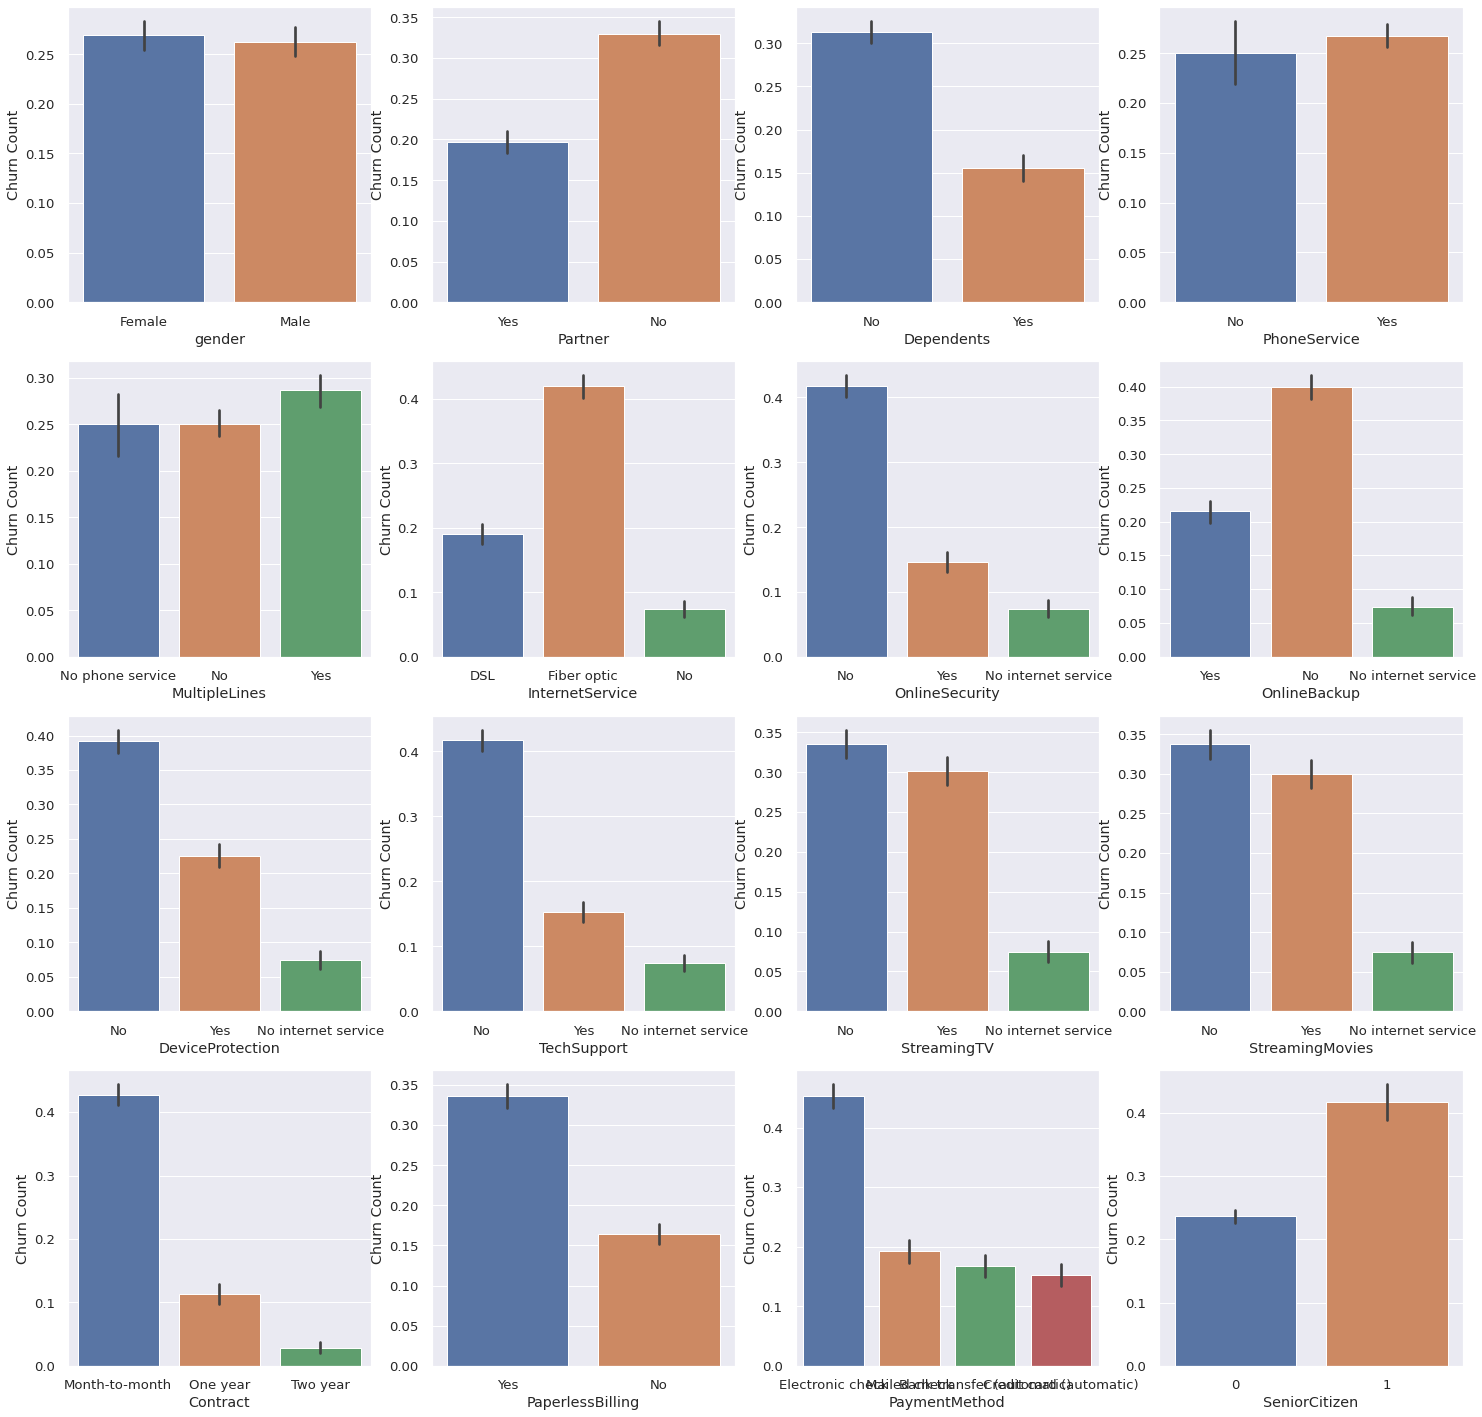

In [26]:
# Plotting how every feature correlate with the "target"
sns.set(font_scale=1.2)
plt.figure(figsize=(25, 25))

for i, column in enumerate(categorical_col, 1):
    plt.subplot(4, 4, i)
    g = sns.barplot(x=column, y='Churn', data=df)
    g.set_xticklabels(g.get_xticklabels())
    plt.ylabel('Churn Count')
    plt.xlabel(f'{column}')

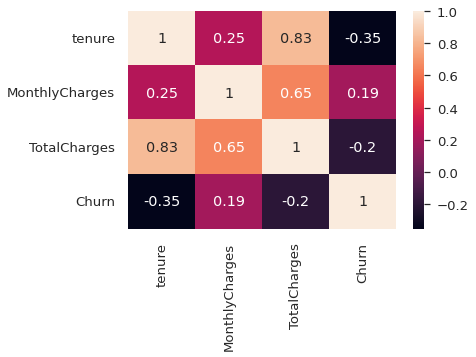

In [27]:
sns.heatmap(df.corr(),annot = True)

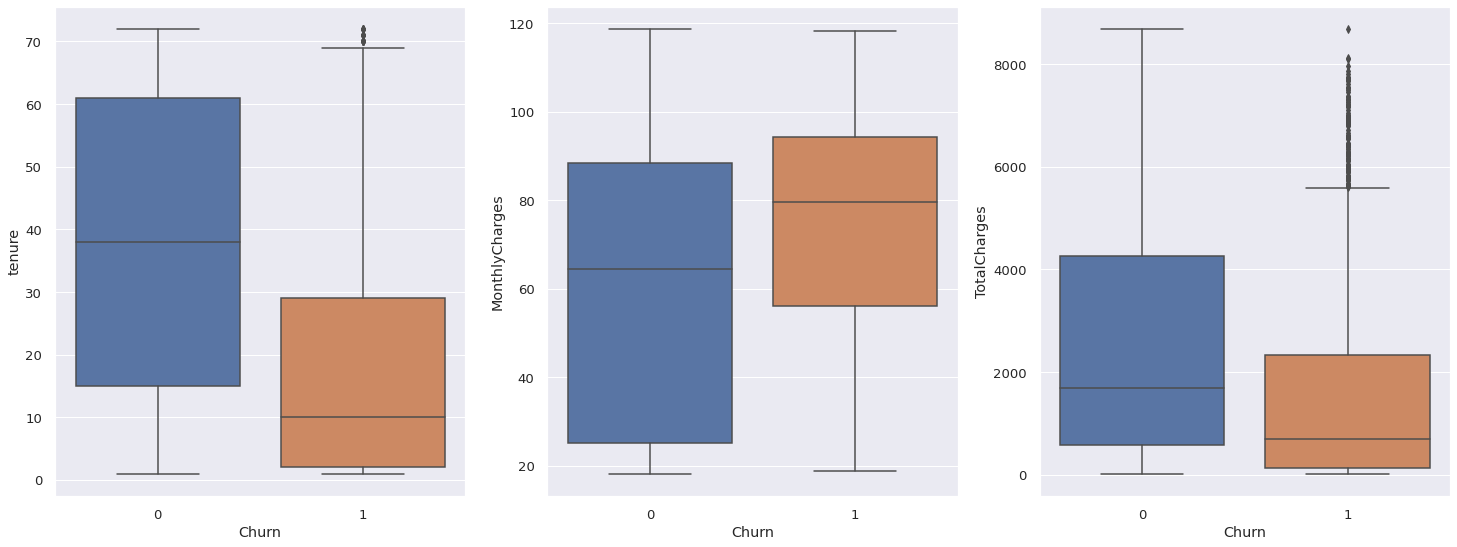

In [28]:
sns.set(font_scale=1.2)
plt.figure(figsize=(25, 9))
for i, column in enumerate(['tenure','MonthlyCharges','TotalCharges'], 1):
    plt.subplot(1, 3, i)
    g = sns.boxplot(y=column, x='Churn', data=df)
    g.set_xticklabels(g.get_xticklabels())

**Answer for Q1**: 
1.   Categorical columns
- `gender` : There is no significant correlation.
- `SeniorCitizen` : senior citizens are more likely to churn.
- `Partner` : customers with no partner are more likely to churn.
- `Dependents` : customers with no dependents are more likely to churn.
- `PhoneService` : there is no significant correlation.
- `MultipleLines` : there is no significant correlation, but customers with multiple lines are slightly more likely to churn.
- `InternetService` : customers with fiber optics are more likely to churn.
- `OnlineSecurity` : customers with no online security are more likely to churn.
- `OnlineBackup` : customers with no online backup are more likely to churn.
- `DeviceProtection` : customers with no device protection is more likely to churn.
- `TechSupport` : customers with no technical support is more likely to churn.
- `StreamingTV` : the customer with no subscription in streaming TV is slightly more probable to churn.
- `StreamingMovies` : the customer with no subscription in streaming Movies is slightly more probable to churn.
- `Contract` : The period of the contract is correlated with the churn. The customers with month-to-month contracts are the most probable customers to churn, while the customers with two years contract is less probable to churn.
- `PaperlessBilling` : The customers who doesn't receive paper billings is more likely to churn.
- `PaymentMethod` : the customer with automatic payment methods (credit card or bank transfer) are the least probable to churn.

2.   Numerical attributes

- `tenure` : the tenure and churn have negative correlation, the more months a customer stays with the company, the less probable for this customer to churn. 
- `MonthlyCharges` : the highest the monthly charges the more probable the customer will churn.
- `TotalCharges` : since the total charges are highly correlated with the tenure, so the total charges is also negatively correlated with the churn.

**Q2: Which payment method has the highest churn rate?**

**Visualization**

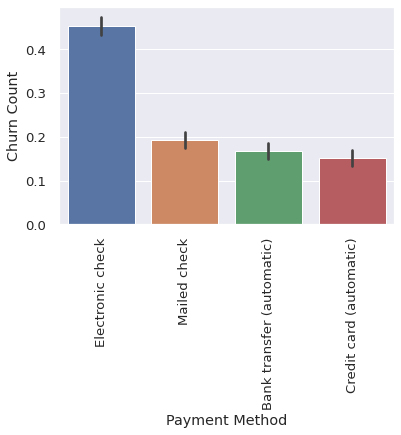

In [29]:
g = sns.barplot(x='PaymentMethod', y='Churn', data=df);
g.set_xticklabels(g.get_xticklabels(),rotation=90);
plt.ylabel('Churn Count');
plt.xlabel('Payment Method');

**Answer for Q2**: 
the electronic check is the payment method with highest churn rate

**Q3: After how many months do customers commonly churn?** (Hint: show and interpret the distribution)

**Visualization**

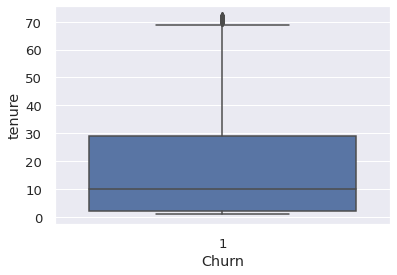

In [30]:
sns.boxplot(x=df[df['Churn'] == 1]['Churn'], y = df['tenure'])

In [31]:
tenures = df[df['Churn'] == 1]['tenure']
tenures.describe()

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64

**Answer for Q3**: By observing the boxplot values, 25% of customers churn haappens after 2 months. 50% of customers churn is after 10 months. and after 29 months, 75% of customers churn have been done.

## Modelling

The contract type can be set to be ordinal attribute.

In [32]:
df['Contract'] = pd.Categorical(df['Contract'],
                                      categories=['Month-to-month', 'One year', 'Two year'],
                                      ordered=True)
df['Contract']

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7027          One year
7028          One year
7029    Month-to-month
7030    Month-to-month
7031          Two year
Name: Contract, Length: 7032, dtype: category
Categories (3, object): ['Month-to-month' < 'One year' < 'Two year']

We need to encode the churn (target)

Encode the categorical variables using one hot encoding

In [33]:
categorical_features = categorical_col.copy()
ordinal_features = ['Contract']
categorical_features.remove('Contract')
print(categorical_features)
print(ordinal_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']
['Contract']


In [34]:
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features)
df_encoded.drop(['gender_Female', 'Partner_No','Dependents_No','PhoneService_No','PaperlessBilling_No','SeniorCitizen_0'], axis='columns', inplace=True)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   tenure                                   7032 non-null   int64   
 1   Contract                                 7032 non-null   category
 2   MonthlyCharges                           7032 non-null   float64 
 3   TotalCharges                             7032 non-null   float64 
 4   Churn                                    7032 non-null   int8    
 5   gender_Male                              7032 non-null   uint8   
 6   Partner_Yes                              7032 non-null   uint8   
 7   Dependents_Yes                           7032 non-null   uint8   
 8   PhoneService_Yes                         7032 non-null   uint8   
 9   MultipleLines_No                         7032 non-null   uint8   
 10  MultipleLines_No phone service      

encode the contract using label encoding

In [35]:
df_encoded['Contract'] = df_encoded['Contract'].astype('category').cat.codes
df_encoded['Contract']

0       0
1       1
2       0
3       1
4       0
       ..
7027    1
7028    1
7029    0
7030    0
7031    2
Name: Contract, Length: 7032, dtype: int8

In [36]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   7032 non-null   int64  
 1   Contract                                 7032 non-null   int8   
 2   MonthlyCharges                           7032 non-null   float64
 3   TotalCharges                             7032 non-null   float64
 4   Churn                                    7032 non-null   int8   
 5   gender_Male                              7032 non-null   uint8  
 6   Partner_Yes                              7032 non-null   uint8  
 7   Dependents_Yes                           7032 non-null   uint8  
 8   PhoneService_Yes                         7032 non-null   uint8  
 9   MultipleLines_No                         7032 non-null   uint8  
 10  MultipleLines_No phone service           7032 no

After encoding all categorical variables, no we will split the dataset into train and test sets with ration 70:30

In [37]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")
        
    elif train==False:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

In [39]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=101)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

## Evaluation

We trained the decision Tree and now it is time to test the model.

In [40]:
print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)

Train Result:
Accuracy Score: 99.82%
_______________________________________________
CLASSIFICATION REPORT:
                     0            1  accuracy    macro avg  weighted avg
precision     0.997494     1.000000  0.998171     0.998747      0.998176
recall        1.000000     0.993279  0.998171     0.996639      0.998171
f1-score      0.998746     0.996628  0.998171     0.997687      0.998170
support    3583.000000  1339.000000  0.998171  4922.000000   4922.000000
_______________________________________________
Confusion Matrix: 
 [[3583    0]
 [   9 1330]]

Test Result:
Accuracy Score: 71.85%
_______________________________________________
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.822222    0.444828  0.718483     0.633525      0.727426
recall        0.796203    0.486792  0.718483     0.641497      0.718483
f1-score      0.809003    0.464865  0.718483     0.636934      0.722561
support    1580.000000  530.000000  

### Comment:
To evaluate the model, we used the recall, precision, f1-score and accuracy as evaluation metrics. The most important metrics is the recall as we need to retrieve all churn customers.
After testing the model using the train and test sets, we got recall of 99.4% on the train set and 46.8% on the test set. The scores in the test set is significantly less than the scores on the train set, from which we can conclude that the model is suffering from overfitting.
To resolve this issue, hyper parameter tuning is needed.

## Hyper parameter tuning

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "criterion":("gini", "entropy"), 
    "splitter":("best", "random"), 
    "max_depth":(list(range(1, 20))), 
    "min_samples_split":[2, 3, 4], 
    "min_samples_leaf":list(range(1, 20)), 
}

tree_clf = DecisionTreeClassifier(random_state=101)
tree_cv = GridSearchCV(tree_clf, params, scoring="recall", n_jobs=-1, verbose=1, cv=3)
tree_cv.fit(X_train, y_train)
best_params = tree_cv.best_params_
print(f"Best paramters: {best_params})")

tree_clf = DecisionTreeClassifier(**best_params)
tree_clf.fit(X_train, y_train)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)

Fitting 3 folds for each of 4332 candidates, totalling 12996 fits
Best paramters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'})
Train Result:
Accuracy Score: 76.43%
_______________________________________________
CLASSIFICATION REPORT:
                     0            1  accuracy    macro avg  weighted avg
precision     0.856638     0.558689  0.764323     0.707663      0.775583
recall        0.812169     0.636296  0.764323     0.724232      0.764323
f1-score      0.833811     0.594972  0.764323     0.714391      0.768836
support    3583.000000  1339.000000  0.764323  4922.000000   4922.000000
_______________________________________________
Confusion Matrix: 
 [[2910  673]
 [ 487  852]]

Test Result:
Accuracy Score: 75.69%
_______________________________________________
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.854015    0.514096  0.756872     0.684055      0

After using GridSearch to find the best parameters for the tree, The best parameters are:
<br>
`{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}`


## Decision Tree Visualization

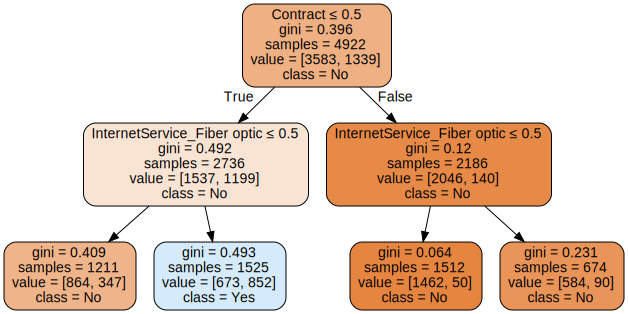

In [42]:
import graphviz
from sklearn.tree import export_graphviz
dot_data = export_graphviz(tree_clf, out_file=None,
                           feature_names=X.columns,
                           class_names=['No', 'Yes'],
                           filled=True, rounded=True,
                           special_characters=True) 
graph = graphviz.Source(dot_data)
graph


**Comments**:
The tree has two splits
The first split is based on the contract and the second split is based on the the internet service type.
The tree has four rules which are:


1.   If contract is month-to-month and the customer's internet service type is not fiber optics, then the customer will not churn
2.   If contract is month-to-month and the customer's internet service type is fiber optics, then the customer will churn

If the contract is year or a two year contract. then the customer will not churn.



## Bonus (Optional)